In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import random

In [2]:
random.seed(42)

branches = [
    {"branch_id": 1, "branch_name": "Gacoan Malang Soekarno Hatta", "city": "Malang"},
    {"branch_id": 2, "branch_name": "Gacoan Malang Sulfat",         "city": "Malang"},
    {"branch_id": 3, "branch_name": "Gacoan Surabaya Gubeng",       "city": "Surabaya"},
    {"branch_id": 4, "branch_name": "Gacoan Surabaya Darmo",        "city": "Surabaya"},
    {"branch_id": 5, "branch_name": "Gacoan Jogja Seturan",         "city": "Yogyakarta"},
]

menus = [
    {"menu_id": 1, "menu_name": "Mie Hompimpa", "category": "Mie",     "price": 18000, "cogs": 8000},
    {"menu_id": 2, "menu_name": "Mie Setan",    "category": "Mie",     "price": 22000, "cogs": 9000},
    {"menu_id": 3, "menu_name": "Mie Iblis",    "category": "Mie",     "price": 25000, "cogs": 10000},
    {"menu_id": 4, "menu_name": "Dimsum Udang", "category": "Dimsum",  "price": 15000, "cogs": 7000},
    {"menu_id": 5, "menu_name": "Es Teh Jumbo", "category": "Minuman", "price": 8000,  "cogs": 3000},
]

records = []
start_date = datetime(2024, 1, 1)

for i in range(500):
    branch  = random.choice(branches)
    menu    = random.choice(menus)
    qty     = random.randint(1, 10)
    date    = start_date + timedelta(days=random.randint(0, 364))
    
    records.append({
        "order_id":    i + 1,
        "branch_id":   branch["branch_id"],
        "branch_name": branch["branch_name"],
        "city":        branch["city"],
        "menu_id":     menu["menu_id"],
        "menu_name":   menu["menu_name"],
        "category":    menu["category"],
        "quantity":    qty,
        "price":       menu["price"],
        "cogs":        menu["cogs"],
        "revenue":     menu["price"] * qty,
        "margin":      (menu["price"] - menu["cogs"]) * qty,
        "order_date":  date.strftime("%Y-%m-%d"),
        "month":       date.strftime("%Y-%m"),
    })

df = pd.DataFrame(records)
print(f"Dataset siap: {len(df)} baris, {len(df.columns)} kolom")
print(df.head())

Dataset siap: 500 baris, 14 kolom
   order_id  branch_id                   branch_name        city  menu_id  \
0         1          1  Gacoan Malang Soekarno Hatta      Malang        1   
1         2          2          Gacoan Malang Sulfat      Malang        2   
2         3          5          Gacoan Jogja Seturan  Yogyakarta        1   
3         4          1  Gacoan Malang Soekarno Hatta      Malang        1   
4         5          2          Gacoan Malang Sulfat      Malang        5   

      menu_name category  quantity  price  cogs  revenue  margin  order_date  \
0  Mie Hompimpa      Mie         5  18000  8000    90000   50000  2024-05-05   
1     Mie Setan      Mie         2  22000  9000    44000   26000  2024-12-12   
2  Mie Hompimpa      Mie        10  18000  8000   180000  100000  2024-08-04   
3  Mie Hompimpa      Mie         2  18000  8000    36000   20000  2024-04-21   
4  Es Teh Jumbo  Minuman        10   8000  3000    80000   50000  2024-01-14   

     month  
0  2024-0

In [3]:
# 1. Hitung Total Revenue dan Total Margin per Menu
# Kita gunakan grouping layaknya SQL GROUP BY
menu_performance = df.groupby('menu_name').agg({
    'quantity': 'sum',
    'revenue': 'sum',
    'margin': 'sum'
}).sort_values(by='margin', ascending=False)

# 2. Tampilkan hasilnya
menu_performance

,quantity,revenue,margin
menu_name,,,
Mie Setan,643,14146000,8359000
Mie Iblis,545,13625000,8175000
Mie Hompimpa,590,10620000,5900000
Dimsum Udang,560,8400000,4480000
Es Teh Jumbo,477,3816000,2385000


In [7]:
# Membuat Pivot Table untuk melihat performa kategori per kota
branch_comparison = df.pivot_table(
    index='city', 
    columns='category', 
    values='revenue', 
    aggfunc='sum'
).fillna(0) # Mengisi data kosong (jika ada cabang yang tidak jual kategori tertentu) dengan 0

# Tampilkan hasilnya
branch_comparison


category,Dimsum,Mie,Minuman
city,,,
Malang,3765000,15204000,1400000
Surabaya,2955000,14301000,1792000
Yogyakarta,1680000,8886000,624000


In [9]:
total_revenue = df['revenue'].sum()

# Gunakan f-string agar hasilnya rapi dengan format Rupiah
print(f"Total Revenue Nasional: Rp {total_revenue:,}")

Total Revenue Nasional: Rp 50,607,000


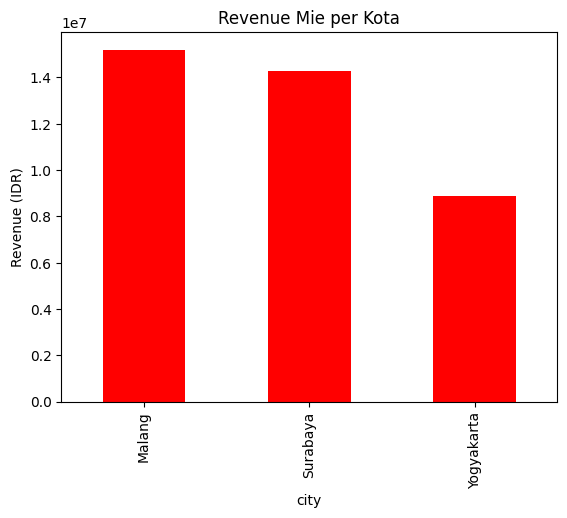

In [10]:
import matplotlib.pyplot as plt

# Membuat visualisasi sederhana
branch_comparison['Mie'].plot(kind='bar', color='red', title='Revenue Mie per Kota')
plt.ylabel('Revenue (IDR)')
plt.show()

In [11]:
# Menghitung persentase margin tiap baris
df['margin_pct'] = (df['margin'] / df['revenue']) * 100

# Tampilkan rata-rata margin nasional
avg_margin = df['margin_pct'].mean()
print(f"Rata-rata Margin Nasional: {avg_margin:.2f}%")

Rata-rata Margin Nasional: 57.95%
